In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE


In [3]:
df = pd.read_csv('kidney_disease.csv')
df.head()


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
df.columns.tolist()


['id',
 'age',
 'bp',
 'sg',
 'al',
 'su',
 'rbc',
 'pc',
 'pcc',
 'ba',
 'bgr',
 'bu',
 'sc',
 'sod',
 'pot',
 'hemo',
 'pcv',
 'wc',
 'rc',
 'htn',
 'dm',
 'cad',
 'appet',
 'pe',
 'ane',
 'classification']

In [5]:
df.isnull().sum()


id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [6]:
df.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [7]:
# 3. Clean messy characters in all columns 
# Strip whitespace and tabs from all string values
df = df.applymap(lambda x: str(x).strip().replace('\t', '') if isinstance(x, str) else x)

# Replace '?' with NaN
df = df.replace('?', np.nan)


C:\Users\vansh\AppData\Local\Temp\ipykernel_63040\688554164.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: str(x).strip().replace('\t', '') if isinstance(x, str) else x)


In [8]:
#4. Fix numeric columns that are stored as text
num_fix_cols = ['pcv', 'wc', 'rc']

for col in num_fix_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [9]:
#Clean the target variable (classification
df['classification'] = df['classification'].str.replace('\t', '').str.strip()
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})


In [10]:
#6. Identify features
target = 'classification'

X = df.drop(columns=[target])
y = df[target]


In [11]:
#7. Separate numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)


Numeric Columns: ['id', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Categorical Columns: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [12]:
#8. Train-test split (IMPORTANT: before SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [13]:
#9. Build Transformers for preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


In [14]:
# 10. Fit preprocessing on train & transform both

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)


In [15]:
#11. Apply SMOTE on the processed training set
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_processed, y_train)


In [16]:
#. Import required ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt


In [17]:
#2. Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True),  # probability=True needed for ROC curve
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}


In [18]:
#3. Train + evaluate each model
results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train_resampled, y_train_resampled)

    # predictions
    y_pred = model.predict(X_test_processed)

    # probabilities (for ROC) — some models need predict_proba
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_processed)[:, 1]
    else:
        y_proba = None

    # evaluation
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    roc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    print("ROC AUC:", roc)

    # store results
    results[name] = {
        "model": model,
        "accuracy": acc,
        "confusion_matrix": cm,
        "roc_auc": roc
    }



===== Logistic Regression =====
Accuracy: 0.9875

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

Confusion Matrix:
[[30  0]
 [ 1 49]]
ROC AUC: 1.0

===== KNN =====
Accuracy: 0.975

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80

Confusion Matrix:
[[30  0]
 [ 2 48]]
ROC AUC: 1.0

===== SVM =====
Accuracy: 0.9875

Classification Report:
              precision    recall  f1-score   support

  

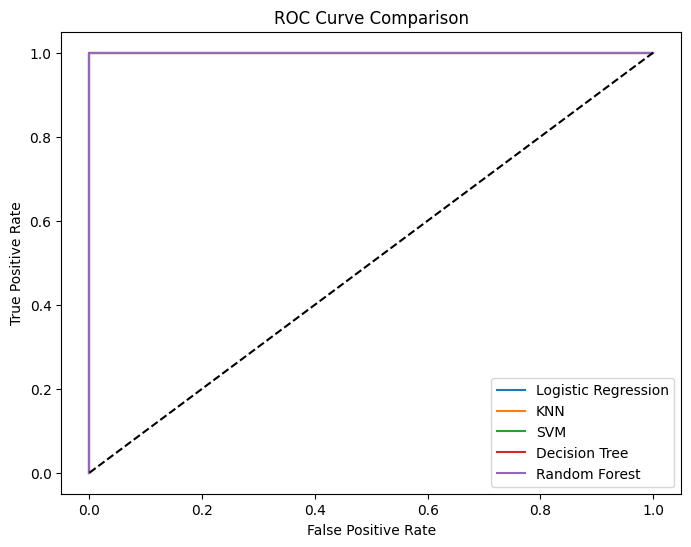

In [19]:
#plotting all ROC curves on one graph
plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_processed)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name}")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()



The ROC curves for all models almost perfectly overlap because all models achieve near-perfect classification on this dataset. This is likely due to the clearly separable nature of the clinical features and the effect of SMOTE, which balances the classes and provides easier decision boundaries. Therefore, all models reach an AUC close to 1.0 and produce visually identical ROC curves

In [20]:
from sklearn.ensemble import VotingClassifier


In [21]:
#soft voting ensemble
soft_voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000)),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
        ("svm", SVC(probability=True))
    ],
    voting="soft"
)


In [22]:
#train
soft_voting.fit(X_train_resampled, y_train_resampled)


VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=2000)),
                             ('knn', KNeighborsClassifier()),
                             ('svm', SVC(probability=True))],
                 voting='soft')

In [23]:
#evaluate
y_pred_soft = soft_voting.predict(X_test_processed)
y_proba_soft = soft_voting.predict_proba(X_test_processed)[:, 1]

print("Soft Voting Accuracy:", accuracy_score(y_test, y_pred_soft))
print("\nClassification Report (Soft Voting):")
print(classification_report(y_test, y_pred_soft))
print("Confusion Matrix (Soft Voting):")
print(confusion_matrix(y_test, y_pred_soft))
print("ROC AUC:", roc_auc_score(y_test, y_proba_soft))


Soft Voting Accuracy: 0.9875

Classification Report (Soft Voting):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

Confusion Matrix (Soft Voting):
[[30  0]
 [ 1 49]]
ROC AUC: 1.0


In [24]:
#hard voting ensemble
hard_voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000)),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
        ("svm", SVC())  # probability not required
    ],
    voting="hard"
)


In [25]:
#train
hard_voting.fit(X_train_resampled, y_train_resampled)


VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=2000)),
                             ('knn', KNeighborsClassifier()), ('svm', SVC())])

In [26]:
#evaluate
y_pred_hard = hard_voting.predict(X_test_processed)

print("Hard Voting Accuracy:", accuracy_score(y_test, y_pred_hard))
print("\nClassification Report (Hard Voting):")
print(classification_report(y_test, y_pred_hard))
print("Confusion Matrix (Hard Voting):")
print(confusion_matrix(y_test, y_pred_hard))


Hard Voting Accuracy: 0.9875

Classification Report (Hard Voting):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

Confusion Matrix (Hard Voting):
[[30  0]
 [ 1 49]]


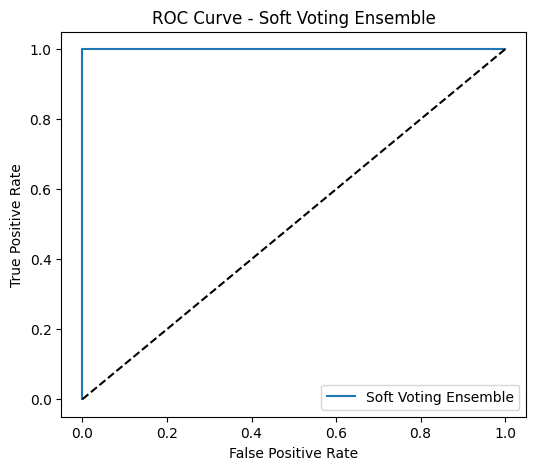

In [27]:
#Plot ROC for Soft Voting Ensemble
fpr, tpr, _ = roc_curve(y_test, y_proba_soft)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Soft Voting Ensemble")
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Soft Voting Ensemble")
plt.legend()
plt.show()


In [28]:
who

ColumnTransformer	 DecisionTreeClassifier	 KNeighborsClassifier	 LogisticRegression	 OneHotEncoder	 Pipeline	 RandomForestClassifier	 SMOTE	 SVC	 
SimpleImputer	 StandardScaler	 VotingClassifier	 X	 X_test	 X_test_processed	 X_train	 X_train_processed	 X_train_resampled	 
acc	 accuracy_score	 categorical_cols	 categorical_transformer	 classification_report	 cm	 col	 confusion_matrix	 df	 
fpr	 hard_voting	 model	 models	 models_list	 name	 np	 num_fix_cols	 numeric_cols	 
numeric_transformer	 pd	 plt	 preprocess	 results	 roc	 roc_auc_score	 roc_curve	 sm	 
soft_voting	 target	 tpr	 train_test_split	 y	 y_pred	 y_pred_hard	 y_pred_soft	 y_proba	 
y_proba_soft	 y_test	 y_train	 y_train_resampled	 


In [29]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Logistic Regression
y_pred_lr = models["Logistic Regression"].predict(X_test_processed)
y_proba_lr = models["Logistic Regression"].predict_proba(X_test_processed)[:,1]
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# KNN
y_pred_knn = models["KNN"].predict(X_test_processed)
y_proba_knn = models["KNN"].predict_proba(X_test_processed)[:,1]
acc_knn = accuracy_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

# SVM
y_pred_svm = models["SVM"].predict(X_test_processed)
# your SVM is probability=True (you said earlier), so predict_proba exists
y_proba_svm = models["SVM"].predict_proba(X_test_processed)[:,1]
acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)

# Decision Tree
y_pred_dt = models["Decision Tree"].predict(X_test_processed)
y_proba_dt = models["Decision Tree"].predict_proba(X_test_processed)[:,1]
acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

# Random Forest
y_pred_rf = models["Random Forest"].predict(X_test_processed)
y_proba_rf = models["Random Forest"].predict_proba(X_test_processed)[:,1]
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)


In [30]:
import pandas as pd
#modelcomparisioncharrt
comparison_data = {
    "Model": ["Logistic Regression", "KNN", "SVM", "Decision Tree", "Random Forest",
              "Hard Voting", "Soft Voting"],
    
    "Accuracy": [
        acc_lr, acc_knn, acc_svm, acc_dt, acc_rf,
        accuracy_score(y_test, y_pred_hard),
        accuracy_score(y_test, y_pred_soft)
    ],
    
    "AUC": [
        auc_lr, auc_knn, auc_svm, auc_dt, auc_rf,
        roc_auc_score(y_test, y_pred_hard),      # Hard Voting
        roc_auc_score(y_test, y_proba_soft)      # Soft Voting
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)


                 Model  Accuracy   AUC
0  Logistic Regression    0.9875  1.00
1                  KNN    0.9750  1.00
2                  SVM    0.9875  1.00
3        Decision Tree    1.0000  1.00
4        Random Forest    1.0000  1.00
5          Hard Voting    0.9875  0.99
6          Soft Voting    0.9875  1.00


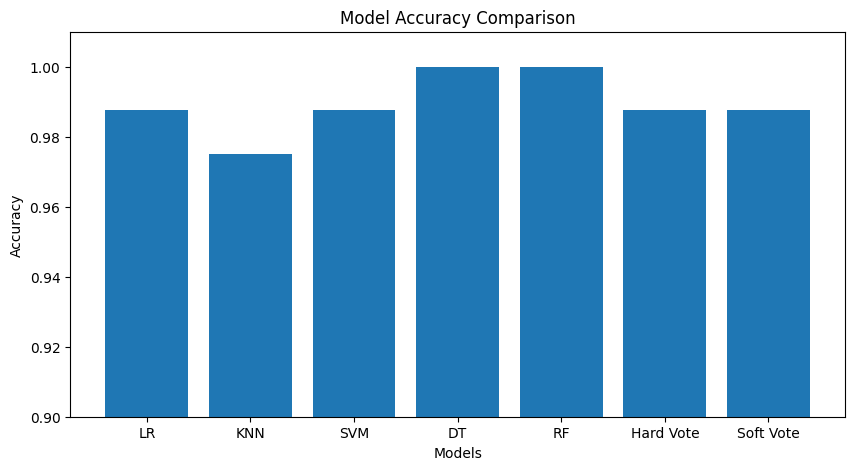

In [31]:
#Accuracy_bar_chart
import matplotlib.pyplot as plt

models_list = ["LR", "KNN", "SVM", "DT", "RF", "Hard Vote", "Soft Vote"]
accuracies = [
    acc_lr, acc_knn, acc_svm, acc_dt, acc_rf,
    accuracy_score(y_test, y_pred_hard),
    accuracy_score(y_test, y_pred_soft)
]

plt.figure(figsize=(10,5))
plt.bar(models_list, accuracies)
plt.ylim(0.90, 1.01)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()


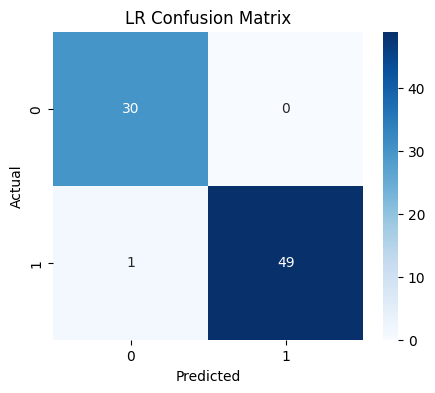

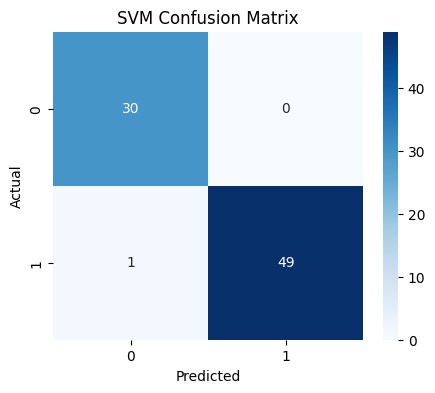

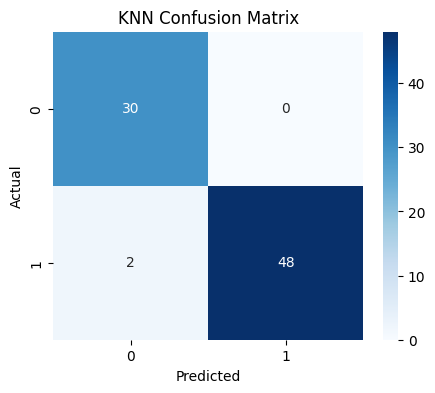

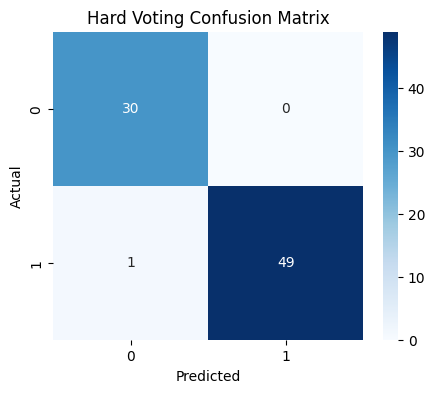

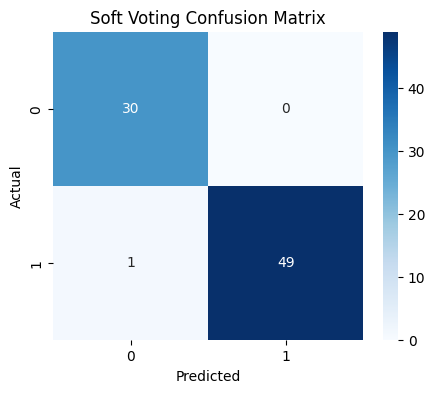

In [33]:
#confusion matrix heatmaps
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Example calls:
plot_cm(y_test, y_pred_lr, "LR Confusion Matrix")
plot_cm(y_test, y_pred_svm, "SVM Confusion Matrix")
plot_cm(y_test, y_pred_knn, "KNN Confusion Matrix")
plot_cm(y_test, y_pred_hard, "Hard Voting Confusion Matrix")
plot_cm(y_test, y_pred_soft, "Soft Voting Confusion Matrix")
